In [1]:
import numpy as np
from scipy.spatial import Delaunay
import pyomo.environ as pyo
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget  
import os
from PIL import Image  # pip install pillow


In [2]:
class GaussianModel:
    """
    f_s(x,y) = - depth * exp(- ||(x,y)-center||^2 / width^2 )
               + bias_strength * ||(x,y)-bias_center||^2
               + offset
    总目标 = sum_s p_s * f_s(x,y)
    适合 ipopt (因为有 exp)
    """

    def build_model(self):
        """
        返回:
            m   : Pyomo ConcreteModel(), 里面有 m.x, m.y (带bounds)
            fsv : [m.x, m.y] 供后续 generate_corners 用
        你可以在这里自由改定义域，后面代码会自动读 fsv 的 lb/ub。
        """
        m = pyo.ConcreteModel()
        m.x = pyo.Var(bounds=(-10.0, 10.0))
        m.y = pyo.Var(bounds=(-10.0, 10.0))
        fsv = [m.x, m.y]
        return m, fsv

    def random_scenarios(self,
                         num_scenarios,
                         x_low, x_high,
                         y_low, y_high,
                         depth_range=(0.8, 2.0),
                         width_range=(0.8, 2.0),
                         bias_strength_range=(0.02, 0.08),
                         offset=0.0,
                         seed=None):
        """
        生成一组场景，每个场景是:
            {
                "p": float,
                "params": {
                    "center": (cx, cy),
                    "depth": depth,
                    "width": width,
                    "bias_strength": bs,
                    "bias_center": (bx, by),
                    "offset": offset,
                }
            }
        """
        rng = np.random.default_rng(seed)
        scens = []

        bx = 0.5*(x_low + x_high)
        by = 0.5*(y_low + y_high)

        for _ in range(num_scenarios):
            cx = rng.uniform(x_low,  x_high)
            cy = rng.uniform(y_low,  y_high)

            depth = rng.uniform(*depth_range)
            width = rng.uniform(*width_range)
            bs    = rng.uniform(*bias_strength_range)

            scens.append({
                "p": 1.0 / num_scenarios,
                "params": {
                    "center": (float(cx), float(cy)),
                    "depth": float(depth),
                    "width": float(width),
                    "bias_strength": float(bs),
                    "bias_center": (float(bx), float(by)),
                    "offset": float(offset),
                }
            })
        return scens

    @staticmethod
    def f_single_numpy(x, y, params):
        cx, cy = params["center"]
        depth  = params["depth"]
        width  = params["width"]
        bs     = params["bias_strength"]
        bx, by = params["bias_center"]
        offset = params["offset"]

        well_term = - depth * np.exp(-(((x-cx)**2 + (y-cy)**2)/(width**2)))
        bias_term = bs * ((x-bx)**2 + (y-by)**2)
        return well_term + bias_term + offset

    @staticmethod
    def f_single_expr(m, params):
        cx, cy = params["center"]
        depth  = params["depth"]
        width  = params["width"]
        bs     = params["bias_strength"]
        bx, by = params["bias_center"]
        offset = params["offset"]

        term_well = -depth * pyo.exp(-(((m.x - cx)**2 + (m.y - cy)**2)/(width**2)))
        term_bias = bs * ((m.x - bx)**2 + (m.y - by)**2)
        return term_well + term_bias + offset

    def f_true_numpy(self, xy, SCENARIOS):
        """
        E[f(x,y)] = sum_s p_s * f_s(x,y)
        """
        x = float(xy[0])
        y = float(xy[1])
        total = 0.0
        for scen in SCENARIOS:
            ps     = float(scen["p"])
            params = scen["params"]
            total += ps * self.f_single_numpy(x, y, params)
        return total

    def f_true_expr(self, m, SCENARIOS):
        """
        Pyomo符号表达式版本的期望目标
        """
        expr = 0
        for scen in SCENARIOS:
            ps     = float(scen["p"])
            params = scen["params"]
            expr  += ps * self.f_single_expr(m, params)
        return expr


class BilinearQPModel:
    """
    f_s(x,y) = a (x-d1)^2 + b (y-d2)^2 - gamma * x * y
    总目标 = sum_s p_s * f_s(x,y)
    允许 x*y 的双线性项 → 非凸二次
    Gurobi 可以解 (NonConvex=2)，Ipopt 也能跑（局部）
    """

    def build_model(self):
        m = pyo.ConcreteModel()
        m.x = pyo.Var(bounds=(-10.0, 10.0))
        m.y = pyo.Var(bounds=(-10.0, 10.0))
        fsv = [m.x, m.y]
        return m, fsv

    def random_scenarios(self,
                         num_scenarios,
                         x_low, x_high,
                         y_low, y_high,
                         a_range=(0.5, 2.0),
                         b_range=(0.5, 2.0),
                         gamma_range=(0.5, 2.0),
                         seed=None):
        """
        返回场景列表:
            {
                "p": float,
                "params": {
                    "a": a_s,
                    "b": b_s,
                    "gamma": gam_s,
                    "d1": d1_s,
                    "d2": d2_s,
                }
            }
        """
        rng = np.random.default_rng(seed)
        scens = []
        for _ in range(num_scenarios):
            a_s   = rng.uniform(*a_range)
            b_s   = rng.uniform(*b_range)
            gam_s = rng.uniform(*gamma_range)

            d1_s  = rng.uniform(x_low, x_high)
            d2_s  = rng.uniform(y_low, y_high)

            scens.append({
                "p": 1.0 / num_scenarios,
                "params": {
                    "a": float(a_s),
                    "b": float(b_s),
                    "gamma": float(gam_s),
                    "d1": float(d1_s),
                    "d2": float(d2_s),
                }
            })
        return scens

    @staticmethod
    def f_single_numpy(x, y, params):
        a_s   = params["a"]
        b_s   = params["b"]
        gam_s = params["gamma"]
        d1_s  = params["d1"]
        d2_s  = params["d2"]

        return (
            a_s * (x - d1_s)**2
          + b_s * (y - d2_s)**2
          - gam_s * (x * y)
        )

    @staticmethod
    def f_single_expr(m, params):
        a_s   = params["a"]
        b_s   = params["b"]
        gam_s = params["gamma"]
        d1_s  = params["d1"]
        d2_s  = params["d2"]

        return (
            a_s * (m.x - d1_s)**2
          + b_s * (m.y - d2_s)**2
          - gam_s * (m.x * m.y)
        )

    def f_true_numpy(self, xy, SCENARIOS):
        x = float(xy[0])
        y = float(xy[1])
        total = 0.0
        for scen in SCENARIOS:
            ps     = float(scen["p"])
            params = scen["params"]
            total += ps * self.f_single_numpy(x, y, params)
        return total

    def f_true_expr(self, m, SCENARIOS):
        expr = 0
        for scen in SCENARIOS:
            ps     = float(scen["p"])
            params = scen["params"]
            expr  += ps * self.f_single_expr(m, params)
        return expr

In [3]:
class RCSModel:
    """
    想法：
    - 把 rcs_problem 这种“场景加权的一阶段非凸代价”包装成和你现有模型一致的接口。
    - 我们用每个场景一套二次/双线性参数，形成非凸目标。
      f_s(x,y) = a x^2 + b y^2 + c x y + d x + e y + f0
    - 总目标 = sum_s p_s * f_s(x,y)

    这个结构：
    - 允许非凸 (c != 0 或 a,b < 0)
    - 没有 exp / log 之类的一般非线性
    - 能被 Gurobi 接（NonConvex=2）和 Ipopt 接
    """

    def build_model(self):
        """
        返回:
            m   : Pyomo ConcreteModel()，包含 m.x, m.y
            fsv : [m.x, m.y] 供后续 generate_corners 用
        这里给定统一的一阶段域，比如 [-10,10]×[-10,10]。
        你可以随便调边界，算法会自动读取这些 bounds 做角点。
        """
        m = pyo.ConcreteModel()
        m.x = pyo.Var(bounds=(-10.0, 10.0))
        m.y = pyo.Var(bounds=(-10.0, 10.0))
        fsv = [m.x, m.y]
        return m, fsv

    def random_scenarios(self,
                         num_scenarios,
                         x_low, x_high,
                         y_low, y_high,
                         a_range=(-2.0, 2.0),
                         b_range=(-2.0, 2.0),
                         c_range=(-3.0, 3.0),
                         d_range=(-5.0, 5.0),
                         e_range=(-5.0, 5.0),
                         f0_range=(-1.0, 1.0),
                         seed=None):
        """
        生成场景列表，每个场景是:
        {
            "p": 1/num_scenarios,
            "params": {
                "a": ...,
                "b": ...,
                "c": ...,
                "d": ...,
                "e": ...,
                "f0": ...
            }
        }

        解释:
          f_s(x,y) = a x^2 + b y^2 + c x y + d x + e y + f0

        我们用随机系数制造不同场景的地形/偏好：
        - a,b 可能为正也可能为负 → 单个场景目标可以是碗也可以是帽
        - c != 0 → 变量间耦合，非对称盆地
        - d,e,f0 让最优点不在原点，而是某个偏移
        """
        rng = np.random.default_rng(seed)
        scens = []
        for _ in range(num_scenarios):
            a_s = rng.uniform(*a_range)
            b_s = rng.uniform(*b_range)
            c_s = rng.uniform(*c_range)
            d_s = rng.uniform(*d_range)
            e_s = rng.uniform(*e_range)
            f0_s= rng.uniform(*f0_range)

            # 为了让每个场景有“自己喜欢”的区域，
            # 我们也可以把 reference point 隐含在 d,e 里：
            #   高概率场景会拉向某个方向，低概率场景可能推到另一个角落。
            # 这里就直接用随机线性项模拟这种偏移。

            scens.append({
                "p": 1.0 / num_scenarios,
                "params": {
                    "a": float(a_s),
                    "b": float(b_s),
                    "c": float(c_s),
                    "d": float(d_s),
                    "e": float(e_s),
                    "f0": float(f0_s),
                }
            })
        return scens

    @staticmethod
    def f_single_numpy(x, y, params):
        """
        单个场景 s 的代价（数值版）
        """
        a = params["a"]
        b = params["b"]
        c = params["c"]
        d = params["d"]
        e = params["e"]
        f0= params["f0"]

        return (
            a * (x**2)
          + b * (y**2)
          + c * (x * y)
          + d * x
          + e * y
          + f0
        )

    @staticmethod
    def f_single_expr(m, params):
        """
        单个场景 s 的代价（Pyomo符号版）
        注意这里不使用非多项式函数，所以 Gurobi (NonConvex=2) 也能理解
        """
        a = params["a"]
        b = params["b"]
        c = params["c"]
        d = params["d"]
        e = params["e"]
        f0= params["f0"]

        return (
            a * (m.x**2)
          + b * (m.y**2)
          + c * (m.x * m.y)
          + d * m.x
          + e * m.y
          + f0
        )

    def f_true_numpy(self, xy, SCENARIOS):
        """
        E[f(x,y)] = sum_s p_s * f_s(x,y)
        这是你算法在节点/三角形/plot里调用的“真实目标值”
        """
        x = float(xy[0])
        y = float(xy[1])
        total = 0.0
        for scen in SCENARIOS:
            ps     = float(scen["p"])
            params = scen["params"]
            total += ps * self.f_single_numpy(x, y, params)
        return total

    def f_true_expr(self, m, SCENARIOS):
        """
        Pyomo 表达式版的期望目标
        这会给你的 ms 子问题、barycentric 内部的小模型用。
        """
        expr = 0
        for scen in SCENARIOS:
            ps     = float(scen["p"])
            params = scen["params"]
            expr  += ps * self.f_single_expr(m, params)
        return expr



===== Iteration 0 =====
UB_global     = 129.709745
LB_iter       = -20.983679
ms_local      = -1.506934e+02
ms_global_act = -1.506934e+02
ms_all_debug  = -1.506934e+02

== Per-triangle summary ==
row\simp  T0*         T1*         
----------------------------------
UB            0.292157    2.555270
LB          -20.983679  -20.983679
ms          -1.507e+02  -1.507e+02
(红色列 = active；第1行=UB，第2行=LB，第3行=ms)


===== Iteration 1 =====
UB_global     = 2.555270
LB_iter       = -70.541248
ms_local      = -7.309652e+01
ms_global_act = -9.052812e+01
ms_all_debug  = -9.052812e+01

== Per-triangle summary ==
row\simp  T0*         T1*         T2*         T3*         
----------------------------------------------------------
UB            2.555270    2.555270    2.555270    2.555270
LB          -87.972846  -73.051156  -70.541248  -87.972846
ms          -9.053e+01  -7.561e+01  -7.310e+01  -9.053e+01
(红色列 = active；第1行=UB，第2行=LB，第3行=ms)


===== Iteration 2 =====
UB_global     = 2.555270
LB_iter       

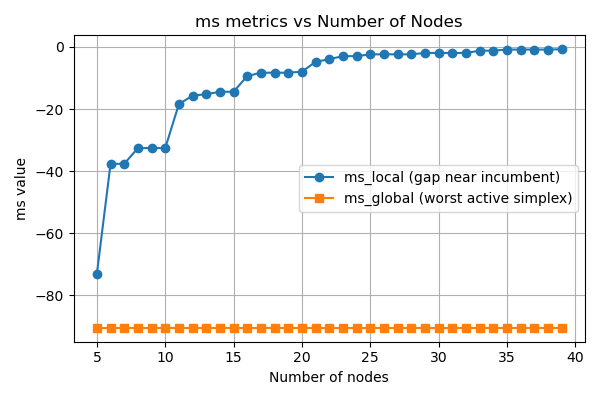


==== Summary Table ====
   Nodes |     ms_local |    ms_global |           LB |           UB
--------------------------------------------------------------------
       4 |    -150.6934 |    -150.6934 |     -20.9837 |     129.7097
       5 |     -73.0965 |     -90.5281 |     -70.5412 |       2.5553
       6 |     -37.6734 |     -90.5281 |     -35.1181 |       2.5553
       7 |     -37.6734 |     -90.5281 |     -35.1181 |       2.5553
       8 |     -32.5860 |     -90.5281 |     -30.0308 |       2.5553
       9 |     -32.5860 |     -90.5281 |     -30.0308 |       2.5553
      10 |     -32.5860 |     -90.5281 |     -30.0308 |       2.5553
      11 |     -18.4349 |     -90.5281 |     -15.8797 |       2.5553
      12 |     -15.6778 |     -90.5281 |     -13.1225 |       2.5553
      13 |     -15.2405 |     -90.5281 |     -12.6853 |       2.5553
      14 |     -14.4386 |     -90.5281 |     -11.8833 |       2.5553
      15 |     -14.4386 |     -90.5281 |     -11.8833 |       2.5553
      16 

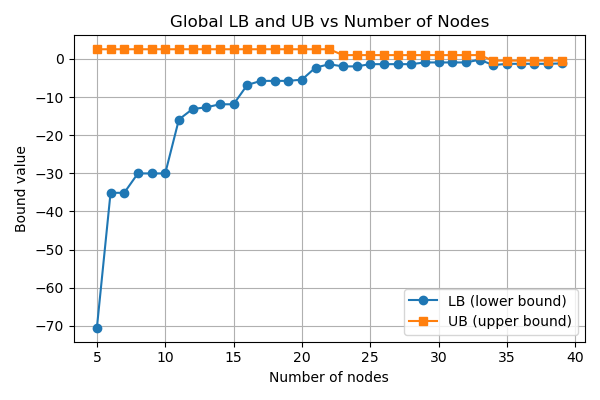

In [5]:
import numpy as np
from scipy.spatial import Delaunay
import pyomo.environ as pyo
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


# ============================================================
# 3. 根据fsv自动生成角点 (2^d个corners)
#    读取每个first-stage变量的lb/ub，构造所有组合
# ============================================================ 
def generate_corners(fsv):
    lows  = []
    highs = []
    for v in fsv:
        lo = v.lb
        hi = v.ub
        if lo is None or hi is None:
            raise ValueError(
                f"Variable {v.name} is missing finite bounds: lb={lo}, ub={hi}"
            )
        if lo > hi:
            raise ValueError(
                f"Variable {v.name} has lb > ub: lb={lo}, ub={hi}"
            )
        lows.append(float(lo))
        highs.append(float(hi))
    lows  = np.array(lows, dtype=float)
    highs = np.array(highs, dtype=float)
    d = len(fsv)
    if d == 0:
        raise ValueError("No first-stage variables in fsv.")
    nodes = []
    for mask in range(1 << d):
        point = []
        for i in range(d):
            if (mask >> i) & 1:
                point.append(highs[i])
            else:
                point.append(lows[i])
        nodes.append(np.array(point, dtype=float))
    return nodes

def bounds_from_fsv(fsv):
    """
    从第一阶段变量列表 fsv 提取每个变量的 (lb, ub)。
    假定是二维 [x, y]。
    返回 ((xL,xU),(yL,yU))
    """
    lows  = [float(v.lb) for v in fsv]
    highs = [float(v.ub) for v in fsv]
    return (lows[0], highs[0]), (lows[1], highs[1])


# ============================================================
# 4. 评估角点的目标值(期望)
#    用当前MODEL/SCENARIOS的 f_true_numpy
# ============================================================
def evaluate_objective_at(node, MODEL, SCENARIOS):
    return MODEL.f_true_numpy(node, SCENARIOS)


# ============================================================
# 5. 在每个三角形里解 ms, LB, UB
#    注意所有值都是"期望目标"
# ============================================================
def minimize_on_each_triangle(nodes, values, MODEL, SCENARIOS,
                              solver='ipopt', tee=False):
    """
    nodes: list of R^2 points
    values: list of MODEL.f_true_numpy(node, SCENARIOS)
    返回:
      tri: Delaunay剖分
      results: 每个三角形的ms/LB/UB等信息
    """
    pts  = np.asarray(nodes, dtype=float)   # (N,2)
    vals = np.asarray(values, dtype=float)  # (N,)
    tri = Delaunay(pts)                     # tri.simplices: (K,3)

    # 用“基模型”骨架，然后在循环里 clone
    m_base, _ = MODEL.build_model()
    opt = pyo.SolverFactory(solver)
    if solver == "gurobi":
        opt.options["NonConvex"] = 2

    results = []
    for k, simp in enumerate(tri.simplices):
        verts  = pts[simp]     # (3,2)
        fverts = vals[simp]    # (3,)

        # 独立模型，避免约束污染
        m = m_base.clone()

        # barycentric λ_j
        m.lam = pyo.Var(range(3), domain=pyo.NonNegativeReals)
        m.lam_sum = pyo.Constraint(expr=sum(m.lam[j] for j in range(3)) == 1.0)

        # x = Σ λ_j * v_jx,  y = Σ λ_j * v_jy
        m.x_link_x = pyo.Constraint(
            expr=m.x == sum(m.lam[j]*float(verts[j,0]) for j in range(3))
        )
        m.x_link_y = pyo.Constraint(
            expr=m.y == sum(m.lam[j]*float(verts[j,1]) for j in range(3))
        )

        # As = Σ λ_j * f(v_j)  (线性插值的代理值)
        m.As = pyo.Var()
        m.As_con = pyo.Constraint(
            expr=m.As == sum(m.lam[j]*float(fverts[j]) for j in range(3))
        )

        # 目标: min [ E[f(x,y)] - As ]
        m.obj = pyo.Objective(
            expr=MODEL.f_true_expr(m, SCENARIOS) - m.As,
            sense=pyo.minimize
        )

        res = opt.solve(m, tee=tee)

        x_ms = np.array([pyo.value(m.x), pyo.value(m.y)], dtype=float)
        ms_val = float(pyo.value(m.obj))       # 该三角形的 ms
        f_at_x_ms = MODEL.f_true_numpy(x_ms, SCENARIOS)  # 真实期望在该点的值

        # LB = min As + ms = min f(v) + ms
        LB = float(np.min(fverts) + ms_val)

        # UB = min( min f(v), f(x_ms) )
        UB = float(min(np.min(fverts), f_at_x_ms))

        results.append({
            "simplex_index": int(k),
            "vertices_index": simp.tolist(),
            "verts": verts,
            "fverts": fverts,
            "x_ms": x_ms,
            "ms": ms_val,
            "LB": LB,
            "UB": UB,
            "f(x_ms)": f_at_x_ms,
            "status": str(res.solver.status),
            "term": str(res.solver.termination_condition),
        })

    return tri, results


# ============================================================
# 6. 全局LB的口径：v*是当前nodes中期望值最小的点
#    LB_iter = f(v*) + max_{Δ包含v*} ms_Δ
# ============================================================
def compute_lb_min_node_max_ms(nodes, values, per_tri):
    idx_min = int(np.argmin(values))
    ms_candidates = [r['ms'] for r in per_tri if idx_min in r['vertices_index']]
    if ms_candidates:
        return float(values[idx_min] + max(ms_candidates)), idx_min, float(max(ms_candidates))
    # fallback（退化情况）
    fallback = float(min(r['LB'] for r in per_tri))
    return fallback, idx_min, float('nan')


# ============================================================
# 7. 选点策略
#    排序 per_tri: 默认 ms 从小到大
#    找一个距离所有已采样节点 >= min_dist 的 x_ms
# ============================================================
def pick_candidate_by_ms_rank(per_tri, nodes, min_dist=1e-6, descending=False):
    cands = sorted(per_tri, key=lambda r: r['ms'], reverse=descending)

    def ok(p):
        return all(np.linalg.norm(p - q) >= min_dist for q in nodes)

    for rank, r in enumerate(cands, start=1):
        p = np.array(r['x_ms'], float)
        if ok(p):
            return p, rank, float(r['ms'])

    return None, None, None


# ============================================================
# 主循环 run_case
# ============================================================
def run_case(init_nodes,
             init_values,
             domain_box,
             MODEL,
             SCENARIOS,
             max_nodes=10,
             solver='ipopt',
             tee=False,
             plot_grid_n=60,
             record_history=True,
             make_3d_plots=True,
             only_from_active=True,
             min_dist=1e-4,
             active_tol=1e-8,
             print_tables=True):
    # 为GIF准备目录
    frame_dir = "frames_tmp"
    os.makedirs(frame_dir, exist_ok=True)

    nodes  = [np.array(p, dtype=float) for p in init_nodes]
    values = [float(v) for v in init_values]

    LB_hist = []
    UB_hist = []
    ms_local_hist = []
    ms_global_hist = []
    node_count = []

    it = 0
    while len(nodes) < max_nodes:
        tri, per_tri = minimize_on_each_triangle(
            nodes, values,
            MODEL=MODEL,
            SCENARIOS=SCENARIOS,
            solver=solver,
            tee=tee
        )

        # 当前节点集中，最小真实期望值 = UB_global
        UB_global = float(np.min(values))

        # LB_iter = f(v*) + max_{Δ包含v*} ms_Δ
        LB_iter, idx_min_node, ms_chosen = compute_lb_min_node_max_ms(
            nodes, values, per_tri
        )
        # ms_chosen 是 “incumbent 邻域的 gap”，就是我们说的 ms_local

        # 识别 active 单形：LB_Δ <= UB_global + active_tol
        active_mask = {
            r['simplex_index']: (r['LB'] <= UB_global + active_tol)
            for r in per_tri
        }
        active_tris = [r for r in per_tri if r['LB'] <= UB_global + active_tol]

        # ms_global = 在 active 集合中最小的 ms
        if len(active_tris) > 0:
            ms_global_now = min(r['ms'] for r in active_tris)
        else:
            # 数值退化 fallback
            ms_global_now = min(r['ms'] for r in per_tri)

        # 历史记录
        if record_history:
            LB_hist.append(LB_iter)
            UB_hist.append(UB_global)
            ms_local_hist.append(ms_chosen)
            ms_global_hist.append(ms_global_now)
            node_count.append(len(nodes))

        # 选择下一个候选采样点
        candidates = active_tris if (only_from_active and len(active_tris) > 0) else per_tri
        if only_from_active and len(active_tris) == 0:
            print(f"[warn] No active simplices this round (tol={active_tol:g}); "
                  f"fall back to all simplices.")

        new_node, used_rank, used_ms = pick_candidate_by_ms_rank(
            candidates, nodes,
            min_dist=min_dist,
            descending=False
        )
        if new_node is None:
            print("All candidates too close; stop.")
            break

        # 输出本轮信息
        if print_tables:
            ms_iter_debug = min(r['ms'] for r in per_tri)
            print(f"\n===== Iteration {it} =====")
            print(f"UB_global     = {UB_global:.6f}")
            print(f"LB_iter       = {LB_iter:.6f}")
            print(f"ms_local      = {ms_chosen:.6e}")
            print(f"ms_global_act = {ms_global_now:.6e}")
            print(f"ms_all_debug  = {ms_iter_debug:.6e}")
            print_per_triangle_table(per_tri, active_mask)

        # 可视化（只有2D的一阶段变量我们才能画曲面）
        if make_3d_plots and len(nodes[0]) == 2:
            fig = plot_iteration(
                it, nodes, tri, active_mask,
                domain_box=domain_box,
                MODEL=MODEL,
                SCENARIOS=SCENARIOS,
                grid_n=plot_grid_n,
                min_node=nodes[idx_min_node],
                new_node=new_node,
                per_tri=per_tri
            )

            # 保存当前迭代图像成一帧
            frame_path = os.path.join("frames_tmp", f"frame_{it:03d}.png")
            fig.savefig(frame_path, dpi=150)
            plt.close(fig)


        # 把新点加入 / 停止条件
        if any(np.linalg.norm(new_node - q) < min_dist for q in nodes):
            print("New node too close to an existing node; stop.")
            break

        nodes.append(new_node)
        values.append(evaluate_objective_at(new_node, MODEL, SCENARIOS))
        it += 1

    return {
        "nodes": np.array(nodes),
        "values": np.array(values),
        "LB_hist": LB_hist,
        "UB_hist": UB_hist,
        "ms_local_hist": ms_local_hist,
        "ms_global_hist": ms_global_hist,
        "node_count": node_count
    }

# ============================================================
# 以下都是每轮迭代中输出表格和图像相关代码
# ============================================================
def print_per_triangle_table(results, active_mask):
    results = sorted(results, key=lambda r: r["simplex_index"])
    simplex_ids = [r["simplex_index"] for r in results]
    active_set = {sid for sid in simplex_ids if active_mask[sid]}

    header = ["row\\simp"] + [f"T{sid}{'*' if sid in active_set else ''}" for sid in simplex_ids]
    rows = [
        ["UB"] + [f"{r['UB']:.6f}" for r in results],
        ["LB"] + [f"{r['LB']:.6f}" for r in results],
        ["ms"] + [f"{r['ms']:.3e}" for r in results],
    ]
    table = [header] + rows

    ncols = len(header)
    colw = [0]*ncols
    for c in range(ncols):
        colw[c] = max(len(str(row[c])) for row in table) + 2

    RED = "\033[31m"
    RESET = "\033[0m"

    def colorize_if_active(col_idx: int, s: str) -> str:
        if col_idx == 0:
            return s
        sid = simplex_ids[col_idx-1]
        return f"{RED}{s}{RESET}" if sid in active_set else s

    header_line = "".join(
        str(header[c]).ljust(colw[c]) if c == 0
        else colorize_if_active(c, str(header[c]).ljust(colw[c]))
        for c in range(ncols)
    )

    print("\n== Per-triangle summary ==")
    print(header_line)
    print("-" * sum(colw))

    for r in rows:
        line = []
        for c in range(ncols):
            cell = str(r[c])
            padded = cell.ljust(colw[c]) if c == 0 else cell.rjust(colw[c])
            line.append(colorize_if_active(c, padded))
        print("".join(line))

    print("(红色列 = active；第1行=UB，第2行=LB，第3行=ms)\n")


# ============================================================
# 8. 每一轮的3D可视化 (期望曲面 + active单形屋顶)
#    注意：现在依赖 MODEL 和 SCENARIOS
# ============================================================
def plot_iteration(iter_id, nodes, tri, active_mask,
                   domain_box,
                   MODEL, SCENARIOS,
                   grid_n=60, elev=35, azim=-135,
                   min_node=None, new_node=None,
                   per_tri=None):

    nodes = np.asarray(nodes, float)

    COLOR_SURFACE = 'C0'
    COLOR_NODE_EDGES = '#444444'
    COLOR_PIECE = '#ff7043'
    LW_MAIN = 2.2

    # 网格 (自动用 domain_box)
    (xL, xU), (yL, yU) = domain_box
    xs = np.linspace(xL, xU, grid_n)
    ys = np.linspace(yL, yU, grid_n)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = np.zeros_like(XX)
    for i in range(XX.shape[0]):
        for j in range(XX.shape[1]):
            ZZ[i, j] = MODEL.f_true_numpy([XX[i, j], YY[i, j]], SCENARIOS)

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(XX, YY, ZZ, alpha=0.35, linewidth=0,
                    antialiased=True, color=COLOR_SURFACE)

    # active 单形的 As+ms 屋顶
    if per_tri is not None and len(per_tri) > 0 and tri is not None:
        faces = []
        for r in per_tri:
            sid = r["simplex_index"]
            if not active_mask.get(sid, False):
                continue
            verts_xy = r["verts"]     # (3,2)
            fverts   = r["fverts"]    # (3,)
            ms_val   = r["ms"]
            tri_xyz  = [
                (verts_xy[i,0], verts_xy[i,1], float(fverts[i] + ms_val))
                for i in range(3)
            ]
            faces.append(tri_xyz)

        if faces:
            coll = Poly3DCollection(
                faces,
                facecolors=[COLOR_PIECE],
                edgecolors='none',
                alpha=0.55
            )
            ax.add_collection3d(coll)

        # active单形屋顶的边线
        for r in per_tri:
            sid = r["simplex_index"]
            if not active_mask.get(sid, False):
                continue
            verts_xy = r["verts"]
            fverts   = r["fverts"]
            ms_val   = r["ms"]
            for i in range(3):
                a_xy = verts_xy[i]
                b_xy = verts_xy[(i+1) % 3]
                za = float(fverts[i] + ms_val)
                zb = float(fverts[(i+1) % 3] + ms_val)
                ax.plot([a_xy[0], b_xy[0]],
                        [a_xy[1], b_xy[1]],
                        [za, zb],
                        lw=LW_MAIN, c=COLOR_PIECE)

    # 真实面上的已采样节点
    node_z = np.array([MODEL.f_true_numpy(p, SCENARIOS) for p in nodes])
    ax.scatter(nodes[:,0], nodes[:,1], node_z,
               s=30, c='k', depthshade=False)

    # active 单形在真实曲面上的边 + 质心
    if tri is not None:
        for k, simp in enumerate(tri.simplices):
            if not active_mask.get(k, False):
                continue
            verts_xy = tri.points[simp]
            for i in range(3):
                a = verts_xy[i]
                b = verts_xy[(i+1) % 3]
                ax.plot([a[0], b[0]], [a[1], b[1]],
                        [MODEL.f_true_numpy(a, SCENARIOS),
                         MODEL.f_true_numpy(b, SCENARIOS)],
                        lw=LW_MAIN, c=COLOR_NODE_EDGES)

            centroid = np.mean(verts_xy, axis=0)
            ax.scatter([centroid[0]], [centroid[1]],
                       [MODEL.f_true_numpy(centroid, SCENARIOS)],
                       marker='^', c=COLOR_NODE_EDGES,
                       s=70, depthshade=False)

    # 当前最优节点 (绿色)
    if min_node is not None:
        ax.scatter([min_node[0]], [min_node[1]],
                   [MODEL.f_true_numpy(min_node, SCENARIOS)],
                   color='g', s=80, marker='o', label='Current min node')

    # 下一轮要加入的新节点 (蓝色)
    if new_node is not None:
        ax.scatter([new_node[0]], [new_node[1]],
                   [MODEL.f_true_numpy(new_node, SCENARIOS)],
                   color='b', s=80, marker='o', label='Next node')

    ax.set_title(f"Iteration {iter_id}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("E[f(x,y)]")
    ax.legend(loc='upper left')
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    return fig



# ============================================================
# 9. 收敛曲线 (LB/UB/ms vs node_count)
# ============================================================
def plot_convergence(hist, prec=4):
    x   = hist["node_count"]
    LB  = hist["LB_hist"]
    UB  = hist["UB_hist"]
    msL = hist["ms_local_hist"]    # incumbent邻域 gap
    msG = hist["ms_global_hist"]   # 所有active单形里最小ms
    '''
    # LB / UB
    plt.figure(figsize=(6,4))
    plt.plot(x, LB, marker='o', label="LB (lower bound)")
    plt.plot(x, UB, marker='s', label="UB (upper bound)")
    plt.xlabel("Number of nodes")
    plt.ylabel("Bound value")
    plt.title("Global LB and UB vs Number of Nodes")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # ms_local vs ms_global
    plt.figure(figsize=(6,4))
    plt.plot(x, msL, marker='o', label="ms_local (gap near incumbent)")
    plt.plot(x, msG, marker='s', label="ms_global (worst active simplex)")
    plt.xlabel("Number of nodes")
    plt.ylabel("ms value")
    plt.title("ms metrics vs Number of Nodes")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    '''
    # LB / UB
    plt.figure(figsize=(6,4))
    plt.plot(x[1:], LB[1:], marker='o', label="LB (lower bound)")
    plt.plot(x[1:], UB[1:], marker='s', label="UB (upper bound)")
    plt.xlabel("Number of nodes")
    plt.ylabel("Bound value")
    plt.title("Global LB and UB vs Number of Nodes")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # ms_local vs ms_global
    plt.figure(figsize=(6,4))
    plt.plot(x[1:], msL[1:], marker='o', label="ms_local (gap near incumbent)")
    plt.plot(x[1:], msG[1:], marker='s', label="ms_global (worst active simplex)")
    plt.xlabel("Number of nodes")
    plt.ylabel("ms value")
    plt.title("ms metrics vs Number of Nodes")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 打印表格
    print("\n==== Summary Table ====")
    fmt = f"{{:.{prec}f}}"
    header = (
        f"{'Nodes':>8s} | "
        f"{'ms_local':>12s} | "
        f"{'ms_global':>12s} | "
        f"{'LB':>12s} | "
        f"{'UB':>12s}"
    )
    print(header)
    print("-" * len(header))
    for n, ms_l, ms_g, lb, ub in zip(x, msL, msG, LB, UB):
        print(
            f"{n:8d} | "
            f"{fmt.format(ms_l):>12s} | "
            f"{fmt.format(ms_g):>12s} | "
            f"{fmt.format(lb):>12s} | "
            f"{fmt.format(ub):>12s}"
        )
    print("-" * len(header))
    print(f"{'Total':>8s} | {len(x):>12d}")



# ============================================================
# 11. main：GaussianModel 示例 (solver=ipopt)
# ============================================================
if __name__ == "__main__":
    # 1) 选择模型
    #MODEL = GaussianModel()      # 你已在上一个 cell 定义好这个 class
    #solver = "ipopt"             # Gaussian 使用 exp，Gurobi不行
    #MODEL = BilinearQPModel()
    MODEL = RCSModel()
    solver = "gurobi"
    max_nodes = 40
    plot_3d = True
    record_hist = True

    # 2) 构建模型并获取变量范围
    model_for_bounds, fsv = MODEL.build_model()
    (xL, xU), (yL, yU) = bounds_from_fsv(fsv)
    domain_box = ((xL, xU), (yL, yU))

    # 3) 生成场景
    SCENARIOS = MODEL.random_scenarios(
        num_scenarios=3,
        x_low=xL, x_high=xU,
        y_low=yL, y_high=yU,
        seed=42
    )

    # 4) 初始化角点和它们的目标值
    init_nodes = generate_corners(fsv)
    init_values = [evaluate_objective_at(p, MODEL, SCENARIOS) for p in init_nodes]

    # 5) 主循环
    hist_simp = run_case(
        init_nodes=init_nodes,
        init_values=init_values,
        domain_box=domain_box,
        MODEL=MODEL,
        SCENARIOS=SCENARIOS,
        max_nodes=max_nodes,
        solver=solver,
        tee=False,
        plot_grid_n=60,
        record_history=record_hist,
        make_3d_plots=plot_3d,
        only_from_active=True,
        min_dist=1e-4,
        active_tol=1e-8,
        print_tables=True
    )
    # === 把保存的帧合成GIF ===
    frame_dir = "frames_tmp"
    frame_files = sorted(
        [f for f in os.listdir(frame_dir) if f.endswith(".png")]
    )

    frames = []
    for fname in frame_files:
        img = Image.open(os.path.join(frame_dir, fname))
        frames.append(img.copy())
        img.close()

    if len(frames) > 0:
        frames[0].save(
            "iteration_progress.gif",
            save_all=True,
            append_images=frames[1:],
            duration=400,  # 每帧0.5秒
            loop=0
        )
        print("[OK] GIF written to iteration_progress.gif")
    else:
        print("[WARN] no frames to build GIF")

    # 6) 收敛图
    plot_convergence(hist_simp, prec=4)

    # 7) 最终结果
    nodes = hist_simp["nodes"]
    values = hist_simp["values"]
    print("\n==== Done ====")
    print(f"Total nodes: {len(nodes)}")
    print(f"Best expected f among nodes: {np.min(values):.6f}")

In [9]:
import numpy as np
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt

def plot_triangulation(points, iteration):
    """
    给定一组点，画出它们的Delaunay三角剖分的连线。
    不显示坐标轴刻度和边框。
    """
    pts = np.array(points)
    tri = Delaunay(pts)

    fig, ax = plt.subplots(figsize=(5,5))

    # 画所有三角形的边
    for simplex in tri.simplices:
        cycle = np.append(simplex, simplex[0])  # 回到起点封闭
        ax.plot(pts[cycle, 0], pts[cycle, 1], color='black', linewidth=1)

    # 画所有采样点（黑点）
    ax.scatter(pts[:,0], pts[:,1], c='black', s=30)

    # 设定范围固定为[0,10]x[0,10]，保持正方形比例
    ax.set_xlim(0,10)
    ax.set_ylim(0,10)
    ax.set_aspect('equal', adjustable='box')

    # 标题（可关）
    ax.set_title(f"Iteration {iteration} (n_points={len(points)})")

    # 去掉坐标轴刻度和边框
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.show()


def run_demo(num_iters=5, seed=0):
    """
    num_iters 是总迭代轮数（包含初始那一轮的绘图）。
    每一轮自动加一个随机点。
    """
    rng = np.random.default_rng(seed)

    # 初始四个角点
    points = [
        (0.0, 0.0),
        (10.0, 0.0),
        (0.0, 10.0),
        (10.0, 10.0),
    ]

    # 画第0轮（只有角点）
    plot_triangulation(points, iteration=0)

    # 后面每一轮加一个点并画图
    for k in range(1, num_iters):
        # 你可以把下面这行换成你的下一个点的规则
        new_pt = (
            float(rng.uniform(0.0, 10.0)),
            float(rng.uniform(0.0, 10.0))
        )
        points.append(new_pt)

        plot_triangulation(points, iteration=k)


if __name__ == "__main__":
    run_demo(num_iters=8, seed=42)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

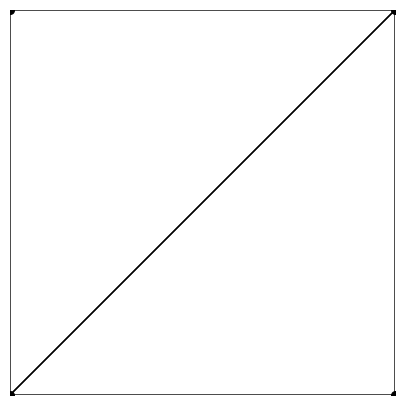

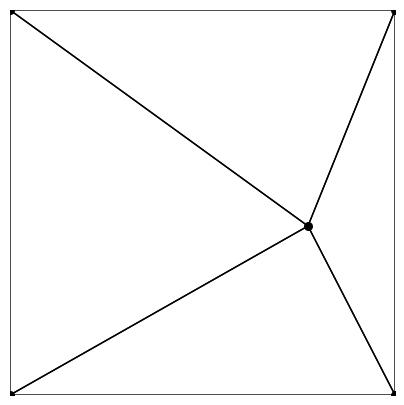

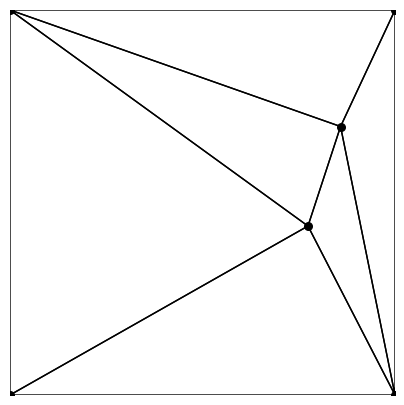

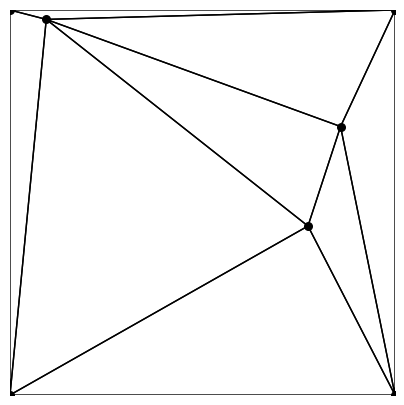

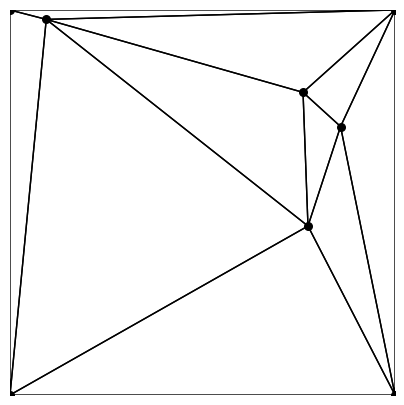

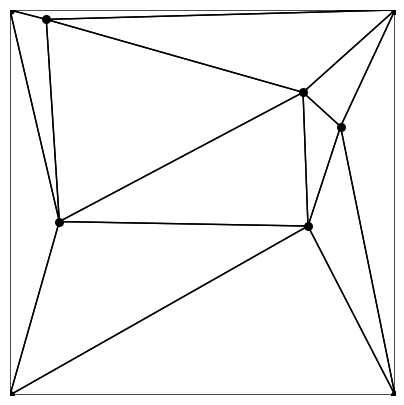

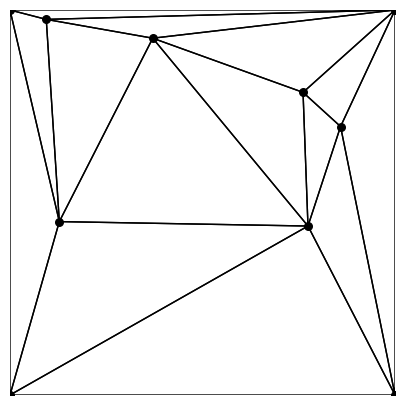

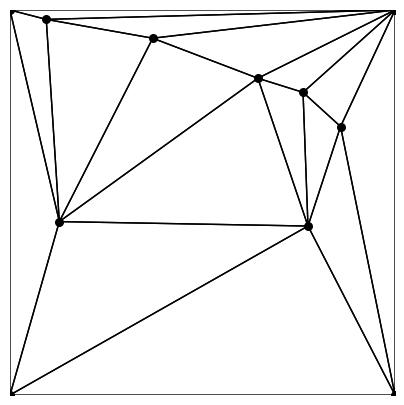

In [12]:
import numpy as np
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
%matplotlib inline


def plot_triangulation(points, iteration):
    """
    给定一组点，画出它们的Delaunay三角剖分的连线。
    不显示坐标轴刻度和边框。
    """
    pts = np.array(points)
    tri = Delaunay(pts)

    fig, ax = plt.subplots(figsize=(5,5))

    # 画所有三角形的边
    for simplex in tri.simplices:
        cycle = np.append(simplex, simplex[0])  # 回到起点封闭
        ax.plot(pts[cycle, 0], pts[cycle, 1], color='black', linewidth=1)

    # 画所有点（黑点）
    ax.scatter(pts[:,0], pts[:,1], c='black', s=30)

    # 固定范围和比例
    ax.set_xlim(0,10)
    ax.set_ylim(0,10)
    ax.set_aspect('equal', adjustable='box')

    # 标题（哪一轮）


    # 去掉坐标轴刻度和边框
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.show()


def run_demo(num_iters=5, seed=0):
    """
    num_iters 是总迭代轮数（包含初始那一轮的绘图）。
    每一轮自动加一个随机点。
    """
    rng = np.random.default_rng(seed)

    # 初始四个角点
    points = [
        (0.0, 0.0),
        (10.0, 0.0),
        (0.0, 10.0),
        (10.0, 10.0),
    ]

    # 第0轮（只有角点）
    plot_triangulation(points, iteration=0)

    # 后面每一轮加一个点并画
    for k in range(1, num_iters):
        # 这里定义“下一点”。你之后可以改成你自己的逻辑
        new_pt = (
            float(rng.uniform(0.0, 10.0)),
            float(rng.uniform(0.0, 10.0))
        )
        points.append(new_pt)

        plot_triangulation(points, iteration=k)

# 直接调用，立刻画出多轮结果
run_demo(num_iters=8, seed=42)
